# 02 — Exploratory Data Analysis

Builds on notebook `01_data_audit.ipynb` and `CLAUDE.md`: the target definition,
censoring treatment, and column-quality findings are re-derived (not re-explained)
below so this notebook runs standalone.


## 1. Load data and re-derive target/censoring

Reload only the columns this notebook needs (full file is 151 columns / 1.6 GB;
this analysis needs ~16) and reapply the `is_resolved` / `is_censored` / `target`
logic from notebook 01.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

GOOD_COLOR = '#4C72B0'
BAD_COLOR = '#C44E52'


In [2]:
DATA_PATH = '../data/accepted_2007_to_2018Q4.csv'

usecols = [
    'id', 'issue_d', 'loan_status', 'term', 'grade', 'sub_grade', 'purpose',
    'fico_range_low', 'dti', 'annual_inc', 'revol_util', 'int_rate', 'loan_amnt',
    'open_acc', 'total_acc', 'mo_sin_old_rev_tl_op', 'bc_util', 'annual_inc_joint',
    'emp_length', 'earliest_cr_line',
]
category_cols = ['term', 'grade', 'sub_grade', 'purpose', 'loan_status', 'emp_length']
dtype_map = {c: 'category' for c in category_cols}

df = pd.read_csv(DATA_PATH, usecols=usecols, dtype=dtype_map, low_memory=False)

# Same trailer-row fix as notebook 01: a few footer rows carry a summary string
# in `id` (not a null), and left in they'd upcast issue_year to float via NaT.
df = df[pd.to_numeric(df['id'], errors='coerce').notnull()].copy()

df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['issue_year'] = df['issue_d'].dt.year
df['issue_quarter'] = df['issue_d'].dt.to_period('Q')

df.shape

(2260668, 22)

In [3]:
# Same fold as notebook 01: credit-policy variants collapse into their
# underlying status; rare `Default` folds into the charged-off/bad side.
credit_policy_variants = {
    'Does not meet the credit policy. Status:Fully Paid': 'Fully Paid',
    'Does not meet the credit policy. Status:Charged Off': 'Charged Off',
}
loan_status_clean = df['loan_status'].astype(object).replace(credit_policy_variants)

resolved_statuses = ['Fully Paid', 'Charged Off', 'Default']
bad_statuses = ['Charged Off', 'Default']

df['is_resolved'] = loan_status_clean.isin(resolved_statuses)
df['is_censored'] = ~df['is_resolved']
df['target'] = np.where(df['is_resolved'], loan_status_clean.isin(bad_statuses).astype(int), np.nan)

df['is_resolved'].mean()


np.float64(0.5963277226023459)

## 2. Default rate by grade

`grade` is meant to be an ordinal risk ranking (A = safest, G = riskiest). Sanity
check: does the realized default rate actually increase monotonically A → G?

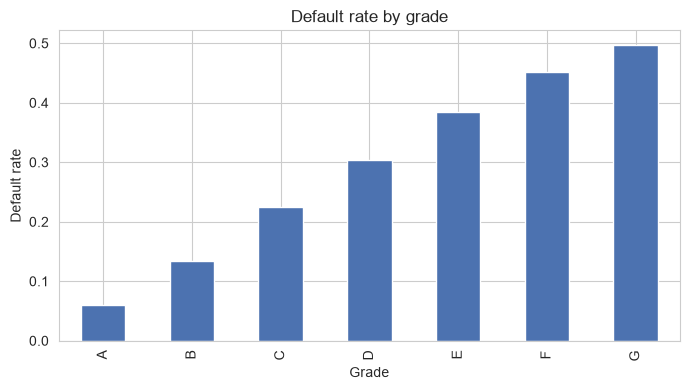

Monotonically increasing A -> G: True


In [4]:
grade_default = df.groupby('grade', observed=True)['target'].mean().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
grade_default.plot(kind='bar', ax=ax, color=GOOD_COLOR)
ax.set_title('Default rate by grade')
ax.set_xlabel('Grade')
ax.set_ylabel('Default rate')
plt.tight_layout()
plt.show()

print('Monotonically increasing A -> G:', grade_default.is_monotonic_increasing)


## 3. Default rate by purpose

Which stated loan purposes carry more risk? Volume is shown alongside rate so a
purpose with only a handful of loans doesn't read as artificially high- or
low-risk.


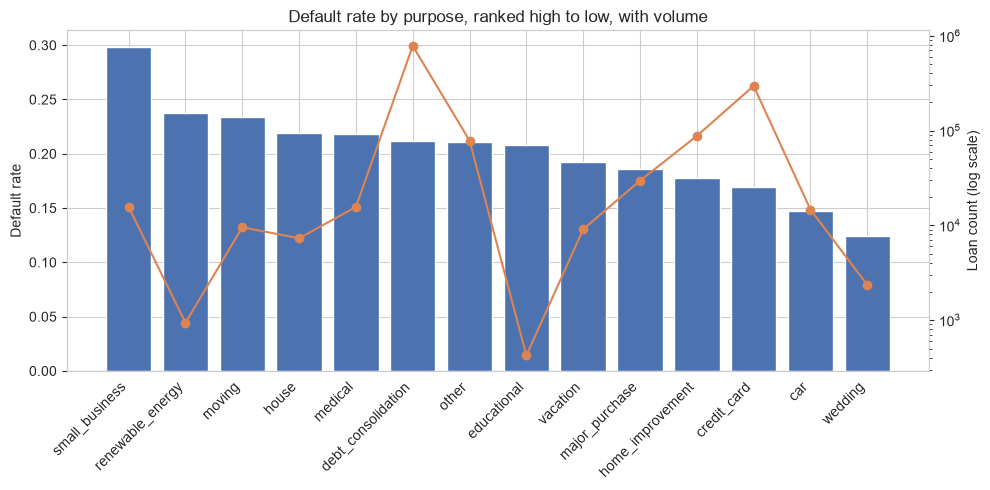

In [5]:
purpose_stats = (
    df.groupby('purpose', observed=True)['target']
    .agg(default_rate='mean', n='count')
    .sort_values('default_rate', ascending=False)
)
x = range(len(purpose_stats))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(x, purpose_stats['default_rate'], color=GOOD_COLOR)
ax1.set_xticks(list(x))
ax1.set_xticklabels(purpose_stats.index, rotation=45, ha='right')
ax1.set_ylabel('Default rate')

ax2 = ax1.twinx()
ax2.plot(x, purpose_stats['n'], color='#DD8452', marker='o')
ax2.set_ylabel('Loan count (log scale)')
ax2.set_yscale('log')
ax2.grid(False)

ax1.set_title('Default rate by purpose, ranked high to low, with volume')
plt.tight_layout()
plt.show()

## 4. Default rate by term

60-month loans are priced and underwritten differently from 36-month loans.
Checking the realized gap, keeping in mind notebook 01's finding that 60-month
cohorts skew more censored (less seasoned on average).


,default_rate,n
term,,
36 months,0.16,1023206
60 months,0.32,324893


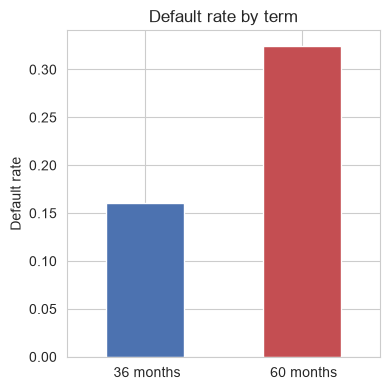

In [6]:
term_stats = df.groupby('term', observed=True)['target'].agg(default_rate='mean', n='count')
display(term_stats)

fig, ax = plt.subplots(figsize=(4, 4))
term_stats['default_rate'].plot(kind='bar', ax=ax, color=[GOOD_COLOR, BAD_COLOR])
ax.set_title('Default rate by term')
ax.set_xlabel('')
ax.set_ylabel('Default rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Default rate trend by origination vintage

How has realized credit quality moved over time? Per notebook 01, recent quarters
are majority-censored — their observed default rate isn't mature yet, so that
region is shaded rather than left to be misread as "recent vintages are safer."


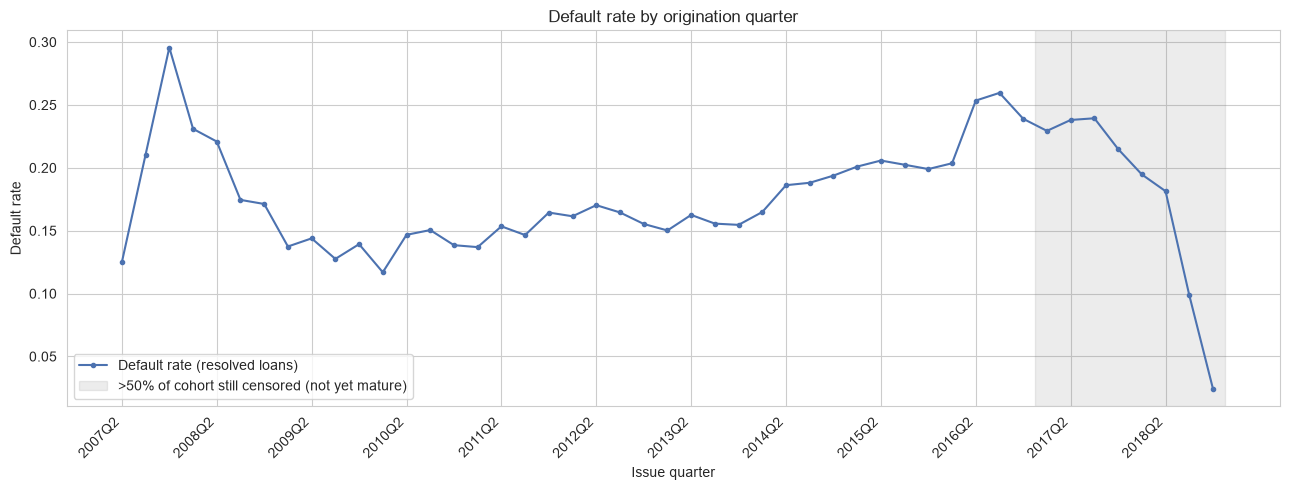

In [7]:
vintage = df.groupby('issue_quarter').agg(
    default_rate=('target', 'mean'),
    censored_rate=('is_censored', 'mean'),
)
vintage.index = vintage.index.astype(str)

fig, ax = plt.subplots(figsize=(13, 5))
x = range(len(vintage))
ax.plot(x, vintage['default_rate'], marker='o', markersize=3, color=GOOD_COLOR,
        label='Default rate (resolved loans)')

immature = vintage.index[vintage['censored_rate'] > 0.5]
if len(immature):
    start_pos = vintage.index.get_loc(immature[0])
    ax.axvspan(start_pos - 0.5, len(vintage) - 0.5, color='grey', alpha=0.15,
               label='>50% of cohort still censored (not yet mature)')

ax.set_xticks(list(x)[::4])
ax.set_xticklabels(vintage.index[::4], rotation=45, ha='right')
ax.set_title('Default rate by origination quarter')
ax.set_xlabel('Issue quarter')
ax.set_ylabel('Default rate')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Numeric feature distributions by outcome

Do the classic underwriting signals separate defaulters from non-defaulters here?
KDEs on the full resolved population (no subsampling). `dti` and `revol_util` are
clipped for plotting only (999 placeholder, >100% values — both flagged as
garbage in notebook 01); `annual_inc` (1,667 exact-zero rows) is plotted on a log
x-axis, so those zeros are excluded rather than breaking `log(0)`.

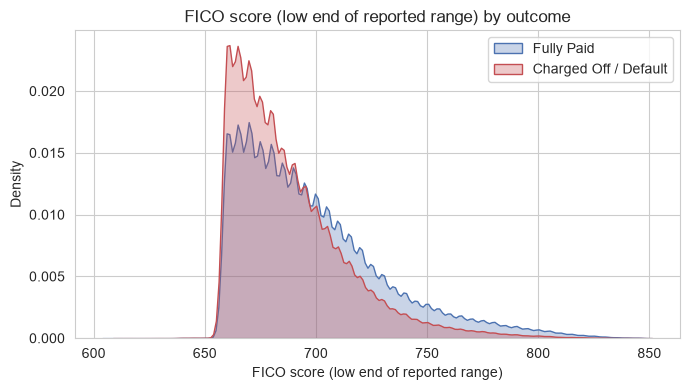

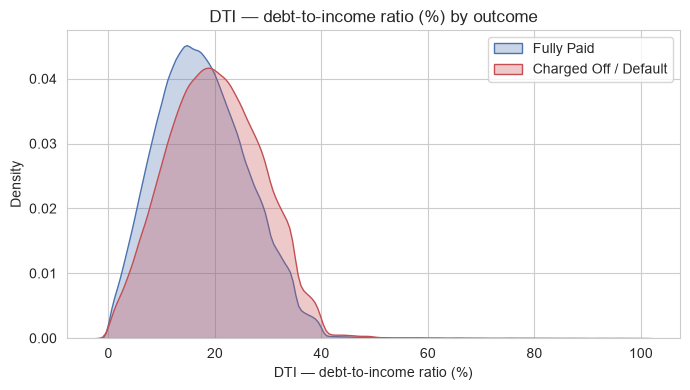

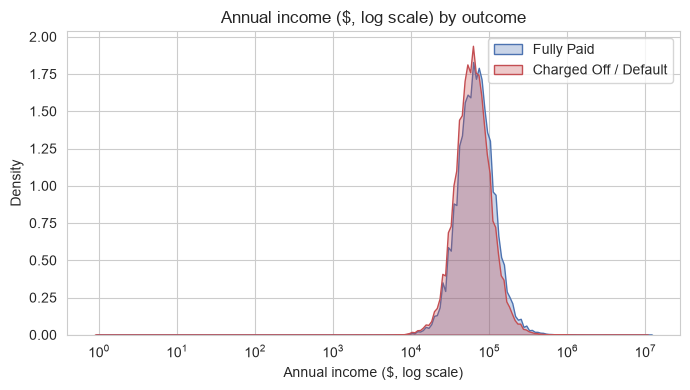

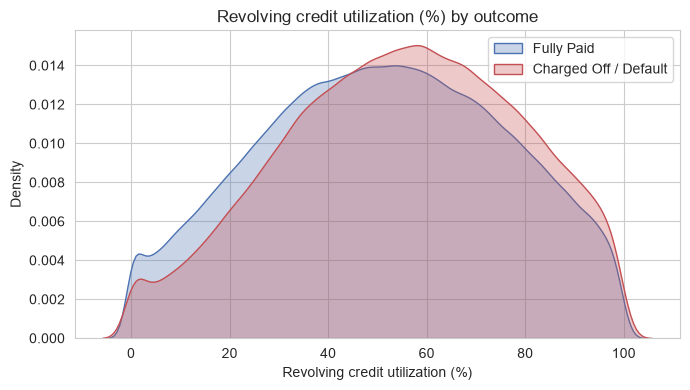

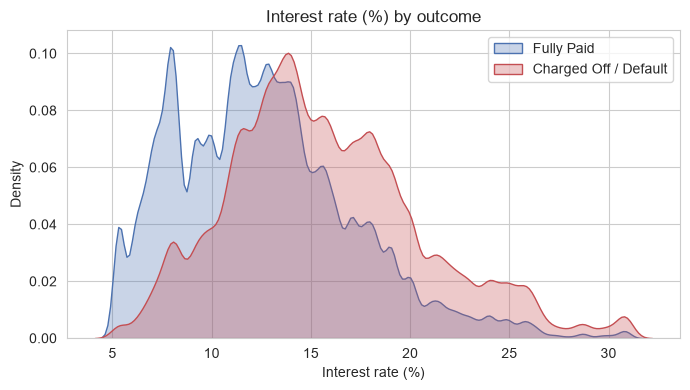

In [8]:
resolved = df[df['is_resolved']].copy()
resolved['target'] = resolved['target'].astype(int)

plot_df = resolved.copy()
plot_df.loc[plot_df['dti'] > 100, 'dti'] = np.nan
plot_df.loc[plot_df['revol_util'] > 100, 'revol_util'] = np.nan
plot_df.loc[plot_df['annual_inc'] <= 0, 'annual_inc'] = np.nan  # log-scale plot can't take 0

feature_labels = {
    'fico_range_low': 'FICO score (low end of reported range)',
    'dti': 'DTI — debt-to-income ratio (%)',
    'annual_inc': 'Annual income ($, log scale)',
    'revol_util': 'Revolving credit utilization (%)',
    'int_rate': 'Interest rate (%)',
}
log_scale_features = {'annual_inc'}

for feat, label in feature_labels.items():
    fig, ax = plt.subplots(figsize=(7, 4))
    data = plot_df[[feat, 'target']].dropna()
    for t, series_label, color in [(0, 'Fully Paid', GOOD_COLOR), (1, 'Charged Off / Default', BAD_COLOR)]:
        sns.kdeplot(
            data.loc[data['target'] == t, feat], ax=ax, label=series_label, fill=True,
            alpha=0.3, color=color, log_scale=(feat in log_scale_features),
        )
    ax.set_title(f'{label} by outcome')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend()
    plt.tight_layout()
    plt.show()

### Age proxies: `emp_length` and `credit_history_years`

The dataset has no raw applicant age. Two fields stand in for it in the eventual
Phase 1 feature set — `emp_length` (employment tenure) and a derived
`credit_history_years` (years between `earliest_cr_line` and `issue_d`). Both are
available before a lending decision is made, so neither runs into the
grade/int_rate framing issue discussed below. Checking them here, in the same
style as the features above, before committing to them in notebook `03_`.

In [9]:
emp_length_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
    '10+ years': 10,
}
# .map() on a categorical Series returns another categorical (categories in the
# order encountered, not numeric order) -- cast to float so groupby/describe
# treat it as an ordered number, not a leftover alphabetical category.
df['emp_length_years'] = df['emp_length'].map(emp_length_map).astype(float)

df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
df['credit_history_years'] = (df['issue_d'] - df['earliest_cr_line']).dt.days / 365.25

# Sanity check: a negative history (earliest line after issue_d) would be a data error.
print('negative credit_history_years:', (df['credit_history_years'] < 0).sum())
df[['emp_length_years', 'credit_history_years']].describe()

negative credit_history_years: 0


,emp_length_years,credit_history_years
count,"2,113,761.00","2,260,639.00"
mean,5.93,16.39
std,3.72,7.68
min,0.00,0.50
25%,2.00,11.25
50%,6.00,14.83
75%,10.00,20.25
max,10.00,83.25


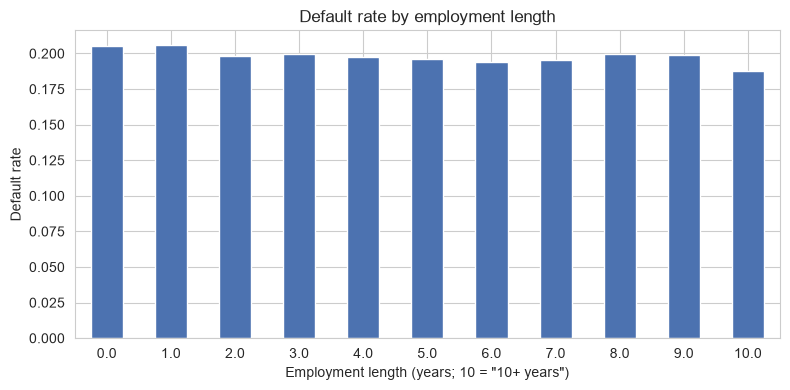

In [10]:
emp_default = df.groupby('emp_length_years')['target'].agg(default_rate='mean', n='count')

fig, ax = plt.subplots(figsize=(8, 4))
emp_default['default_rate'].plot(kind='bar', ax=ax, color=GOOD_COLOR)
ax.set_title('Default rate by employment length')
ax.set_xlabel('Employment length (years; 10 = "10+ years")')
ax.set_ylabel('Default rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

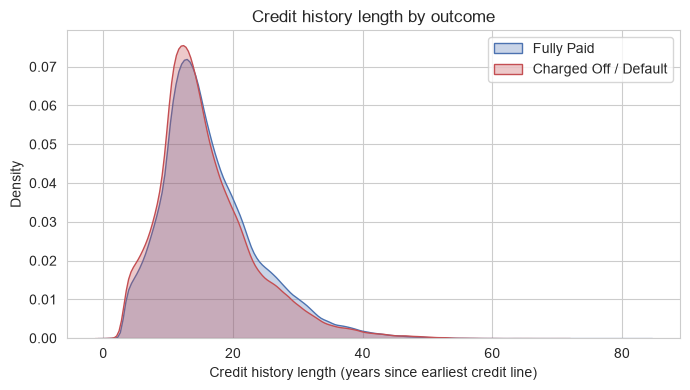

In [11]:
age_resolved = df.loc[df['is_resolved'], ['credit_history_years', 'target']].dropna()
age_resolved['target'] = age_resolved['target'].astype(int)

fig, ax = plt.subplots(figsize=(7, 4))
for t, label, color in [(0, 'Fully Paid', GOOD_COLOR), (1, 'Charged Off / Default', BAD_COLOR)]:
    sns.kdeplot(
        age_resolved.loc[age_resolved['target'] == t, 'credit_history_years'],
        ax=ax, label=label, fill=True, alpha=0.3, color=color,
    )
ax.set_title('Credit history length by outcome')
ax.set_xlabel('Credit history length (years since earliest credit line)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

**Finding:** neither proxy shows much separation. `emp_length_years` is nearly
flat across the full 0-10 range (default rate stays within ~19-21%, no visible
trend) and its correlation with target is negligible (r=-0.01). `credit_history_years`
is weakly better (r=-0.03 — longer history is slightly associated with lower
default) but still far weaker than `fico_range_low` (r=-0.13) or `dti` (r=0.11)
from the previous section. Neither looks like it's carrying much of the signal a
real age field would — worth including in notebook `03_` as weak/marginal
features, not as a load-bearing substitute for age.

## 7. Additional bureau features

Phase 1 modeling (notebook `03_`/`04_`) is being expanded beyond the original
13 features to include seven more application-time bureau attributes not
explored in the EDA pass above: `delinq_2yrs`, `inq_last_6mths`, `mort_acc`,
`pub_rec`, `acc_now_delinq`, `collections_12_mths_ex_med`, and
`mo_sin_old_rev_tl_op`. All are legitimate inputs a real credit report would
supply at application time. Per notebook 01, `mo_sin_old_rev_tl_op` is
schema-absent before ~2012 — profiled here anyway since Phase 1 modeling is
already scoped to `issue_year >= 2013`, where it's populated.

Reload just these seven columns (plus `id`, to merge back into the existing
`df`) rather than the full file.


In [12]:
new_bureau_cols = [
    'delinq_2yrs', 'inq_last_6mths', 'mort_acc', 'pub_rec', 'acc_now_delinq',
    'collections_12_mths_ex_med',
]
bureau_df = pd.read_csv(DATA_PATH, usecols=['id'] + new_bureau_cols, low_memory=False)

# Same trailer-row fix as notebook 01/02 section 1.
bureau_df = bureau_df[pd.to_numeric(bureau_df['id'], errors='coerce').notnull()].copy()

df = df.merge(bureau_df, on='id', how='left')
# Keep the garbage-cleaned frame from section 6 in sync so the extended
# correlation heatmap later in this notebook can reuse its cleaned dti/
# revol_util/annual_inc rather than re-deriving them.
plot_df = plot_df.merge(bureau_df, on='id', how='left')

# mo_sin_old_rev_tl_op was already loaded in section 1's usecols -- no need to
# reload/merge it, just fold it into this section's feature list.
bureau_cols = new_bureau_cols + ['mo_sin_old_rev_tl_op']
df[bureau_cols].isnull().mean()


delinq_2yrs                  0.00
inq_last_6mths               0.00
mort_acc                     0.02
pub_rec                      0.00
acc_now_delinq               0.00
collections_12_mths_ex_med   0.00
mo_sin_old_rev_tl_op         0.03
dtype: float64

`mo_sin_old_rev_tl_op`'s overall null rate above is misleadingly low — it
blends ~100% pre-2012 with ~0% after. Same schema-growth check as notebook 01,
cross-tabbed against `issue_year` directly:


In [13]:
df.groupby('issue_year')['mo_sin_old_rev_tl_op'].apply(lambda x: x.isnull().mean())


issue_year
2007   1.00
2008   1.00
2009   1.00
2010   1.00
2011   1.00
2012   0.52
2013   0.00
2014   0.00
2015   0.00
2016   0.00
2017   0.00
2018   0.00
Name: mo_sin_old_rev_tl_op, dtype: float64

Confirms the schema-growth pattern — effectively unusable before 2012, fully
populated from 2013 on. Not a blocker: Phase 1 modeling is already scoped to
`issue_year >= 2013` (notebook 01), where the field is complete.

Most of the seven new features are low-cardinality counts (0, 1, 2, 3+) rather
than continuous distributions, so each gets a default-rate-by-value bar chart
with volume shown alongside (same style as the `purpose` chart in section 3)
instead of a KDE — a KDE suits a continuous distribution, not a handful of
discrete count values. `mo_sin_old_rev_tl_op` is the exception (a continuous
months-since-oldest-account measure, closer in spirit to `credit_history_years`
in section 6) and is bucketed into year ranges instead of capped counts.


In [14]:
bureau_resolved = df[df['is_resolved']].copy()
bureau_resolved['target'] = bureau_resolved['target'].astype(int)


def bucket_counts(series, cap):
    """Cap a count-like series at `cap`, labeling the tail bucket e.g. '3+'."""
    capped = series.clip(upper=cap)
    labels = capped.astype('Int64').astype(str)
    return labels.where(capped < cap, f'{cap}+')


def plot_default_rate_by_bucket(data, col, order, title, xlabel):
    """Default rate + volume by bucket -- same dual-axis style as the purpose chart in section 3."""
    stats = data.groupby(col, observed=True)['target'].agg(default_rate='mean', n='count').reindex(order)
    x = range(len(stats))

    fig, ax1 = plt.subplots(figsize=(7, 4))
    ax1.bar(x, stats['default_rate'], color=GOOD_COLOR)
    ax1.set_xticks(list(x))
    ax1.set_xticklabels(stats.index)
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel('Default rate')

    ax2 = ax1.twinx()
    ax2.plot(x, stats['n'], color='#DD8452', marker='o')
    ax2.set_ylabel('Loan count (log scale)')
    ax2.set_yscale('log')
    ax2.grid(False)

    ax1.set_title(title)
    plt.tight_layout()
    plt.show()
    return stats


### Delinquency signals: `delinq_2yrs`, `acc_now_delinq`

Both count delinquent accounts, but on different windows — `delinq_2yrs` looks
back over the full 2 years before origination, `acc_now_delinq` is a snapshot
of accounts delinquent *right now*. Both are heavily concentrated at 0, so
bucketed at the tail.


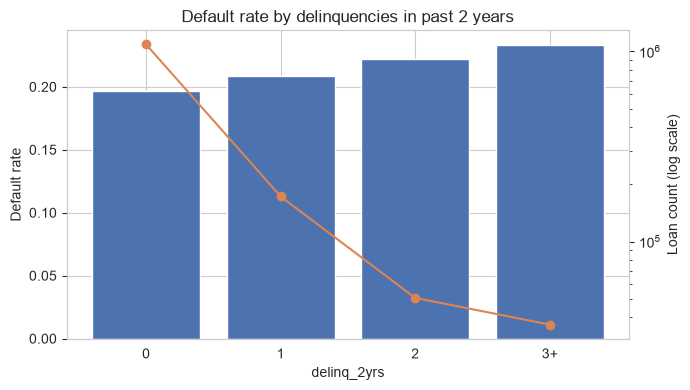

,default_rate,n
delinq_2yrs_bucket,,
0,0.20,1088396
1,0.21,172610
2,0.22,50512
3+,0.23,36581


In [15]:
bureau_resolved['delinq_2yrs_bucket'] = bucket_counts(bureau_resolved['delinq_2yrs'], 3)
plot_default_rate_by_bucket(
    bureau_resolved, 'delinq_2yrs_bucket', ['0', '1', '2', '3+'],
    'Default rate by delinquencies in past 2 years', 'delinq_2yrs',
)


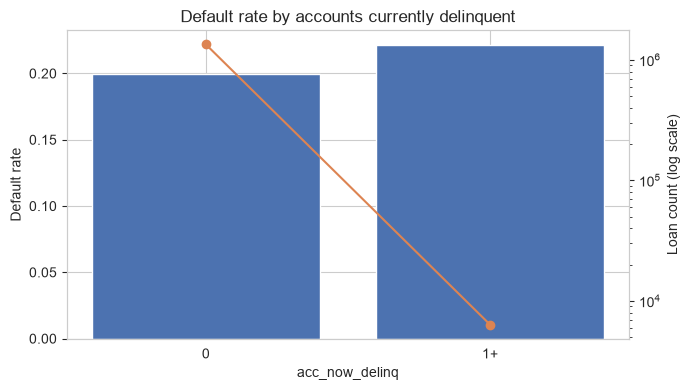

,default_rate,n
acc_now_delinq_bucket,,
0,0.20,1341728
1+,0.22,6371


In [16]:
bureau_resolved['acc_now_delinq_bucket'] = bucket_counts(bureau_resolved['acc_now_delinq'], 1)
plot_default_rate_by_bucket(
    bureau_resolved, 'acc_now_delinq_bucket', ['0', '1+'],
    'Default rate by accounts currently delinquent', 'acc_now_delinq',
)


**Finding:** `delinq_2yrs` rises monotonically as expected — 19.6% (0) →
20.9% (1) → 22.2% (2) → 23.3% (3+), a modest but sensible gradient.
`acc_now_delinq` moves the same direction (20.0% → 22.1%) but the "1+" bucket
is thin (n=6,371 vs. 1.34M at 0) — real signal, but too sparse to lean on
heavily on its own.


### Credit-seeking signal: `inq_last_6mths`

Hard credit inquiries in the 6 months before origination — more inquiries
typically signals more active credit-seeking (and, plausibly, financial
stress).


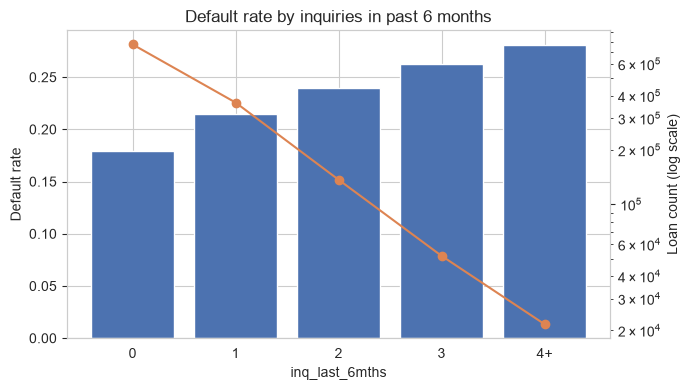

,default_rate,n
inq_last_6mths_bucket,,
0,0.18,770762
1,0.21,366953
2,0.24,136957
3,0.26,51789
4+,0.28,21638


In [17]:
bureau_resolved['inq_last_6mths_bucket'] = bucket_counts(bureau_resolved['inq_last_6mths'], 4)
plot_default_rate_by_bucket(
    bureau_resolved, 'inq_last_6mths_bucket', ['0', '1', '2', '3', '4+'],
    'Default rate by inquiries in past 6 months', 'inq_last_6mths',
)


**Finding:** the cleanest monotonic relationship of the seven new features —
17.9% (0) → 21.4% (1) → 24.0% (2) → 26.3% (3) → 28.1% (4+), a ~10-point spread
with a well-populated tail (4+ still n=21,638). One of the more promising
additions.


### Derogatory records: `pub_rec`, `collections_12_mths_ex_med`

Both flag serious negative events — public records (bankruptcies, liens,
judgments) and third-party collections — rather than routine repayment
behavior.


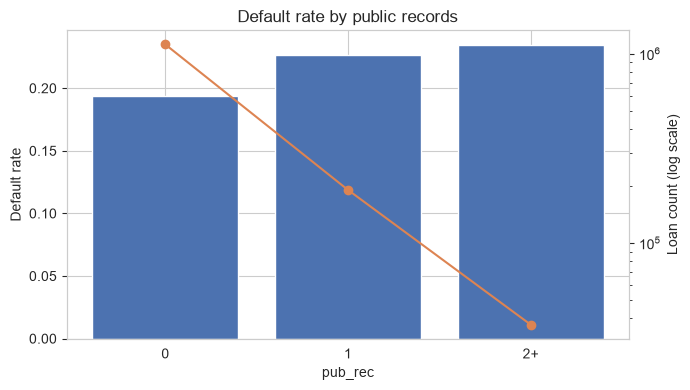

,default_rate,n
pub_rec_bucket,,
0,0.19,1119921
1,0.23,191035
2+,0.23,37143


In [18]:
bureau_resolved['pub_rec_bucket'] = bucket_counts(bureau_resolved['pub_rec'], 2)
plot_default_rate_by_bucket(
    bureau_resolved, 'pub_rec_bucket', ['0', '1', '2+'],
    'Default rate by public records', 'pub_rec',
)


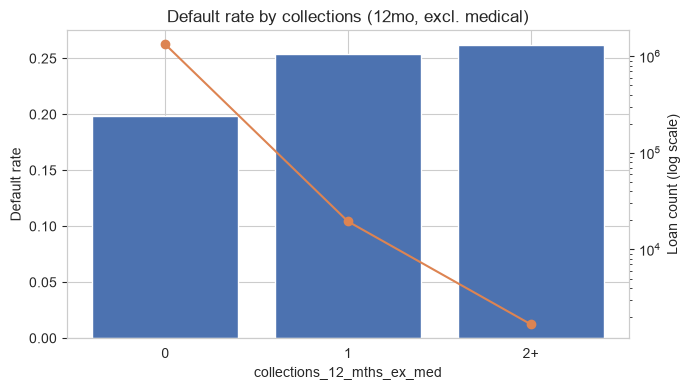

,default_rate,n
collections_12_mths_ex_med_bucket,,
0,0.20,1326911
1,0.25,19504
2+,0.26,1684


In [19]:
bureau_resolved['collections_12_mths_ex_med_bucket'] = bucket_counts(bureau_resolved['collections_12_mths_ex_med'], 2)
plot_default_rate_by_bucket(
    bureau_resolved, 'collections_12_mths_ex_med_bucket', ['0', '1', '2+'],
    'Default rate by collections (12mo, excl. medical)', 'collections_12_mths_ex_med',
)


**Finding:** both rise with more derogatory events as expected — `pub_rec`
19.4% (0) → 22.6% (1) → 23.4% (2+); `collections_12_mths_ex_med` 19.9% (0) →
25.4% (1) → 26.2% (2+). Both are heavily concentrated at 0 (>93% of resolved
loans), so the effect is real but only informative for a small slice of
applicants.


### Account profile: `mort_acc`, `mo_sin_old_rev_tl_op`

Not delinquency signals — these describe the shape and age of an applicant's
credit file rather than repayment problems.


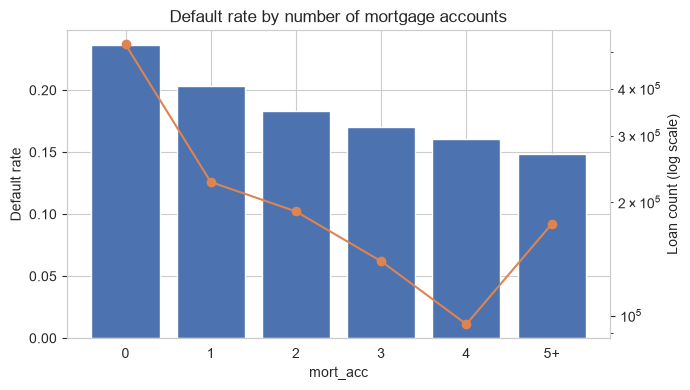

,default_rate,n
mort_acc_bucket,,
0,0.24,523858
1,0.20,226144
2,0.18,188943
3,0.17,139385
4,0.16,94921
5+,0.15,174848


In [20]:
bureau_resolved['mort_acc_bucket'] = bucket_counts(bureau_resolved['mort_acc'], 5)
plot_default_rate_by_bucket(
    bureau_resolved, 'mort_acc_bucket', ['0', '1', '2', '3', '4', '5+'],
    'Default rate by number of mortgage accounts', 'mort_acc',
)


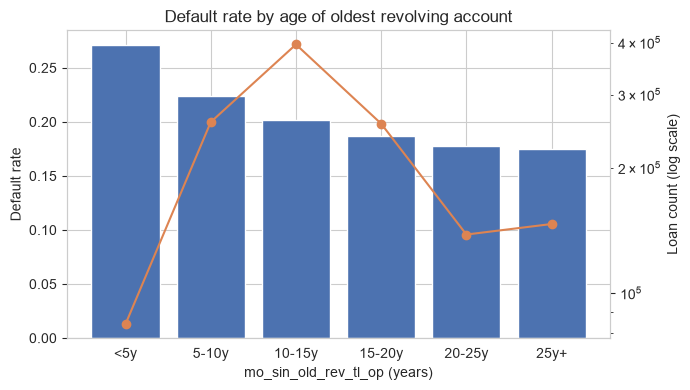

,default_rate,n
mo_sin_old_rev_tl_op_bucket,,
<5y,0.27,84245
5-10y,0.22,257603
10-15y,0.20,395816
15-20y,0.19,255313
20-25y,0.18,138274
25y+,0.18,146571


In [21]:
# Continuous (months since oldest revolving account), not a small count -- bucket
# into year ranges instead of capped integer values, same reasoning as the
# credit_history_years treatment in section 6.
bins = [0, 60, 120, 180, 240, 300, np.inf]
labels = ['<5y', '5-10y', '10-15y', '15-20y', '20-25y', '25y+']
bureau_resolved['mo_sin_old_rev_tl_op_bucket'] = pd.cut(
    bureau_resolved['mo_sin_old_rev_tl_op'], bins=bins, labels=labels,
)
plot_default_rate_by_bucket(
    bureau_resolved, 'mo_sin_old_rev_tl_op_bucket', labels,
    'Default rate by age of oldest revolving account', 'mo_sin_old_rev_tl_op (years)',
)


**Finding:** `mort_acc` is the one surprise here — default rate *falls* as the
count rises (23.6% at 0 mortgages → 14.9% at 5+), the opposite direction of
every delinquency-style feature above. More mortgage accounts more plausibly
proxies homeownership and financial stability than risk — worth keeping the
sign in mind when reading notebook 03's logistic regression coefficients,
since it will point the "safe" direction. `mo_sin_old_rev_tl_op` behaves as
expected for an age-of-credit-file measure — default rate falls steadily from
27.1% (<5 years) to 17.5% (25+ years), similar in spirit to
`credit_history_years` in section 6.


## 8. Correlation among key numeric features

Checking for multicollinearity across the full Phase 1 candidate feature set. Redundant features inflate logistic regression coefficient
variance and waste LightGBM splits. `int_rate` is excluded since it isn't part
of the Phase 1 feature set anyway (see product framing note below).


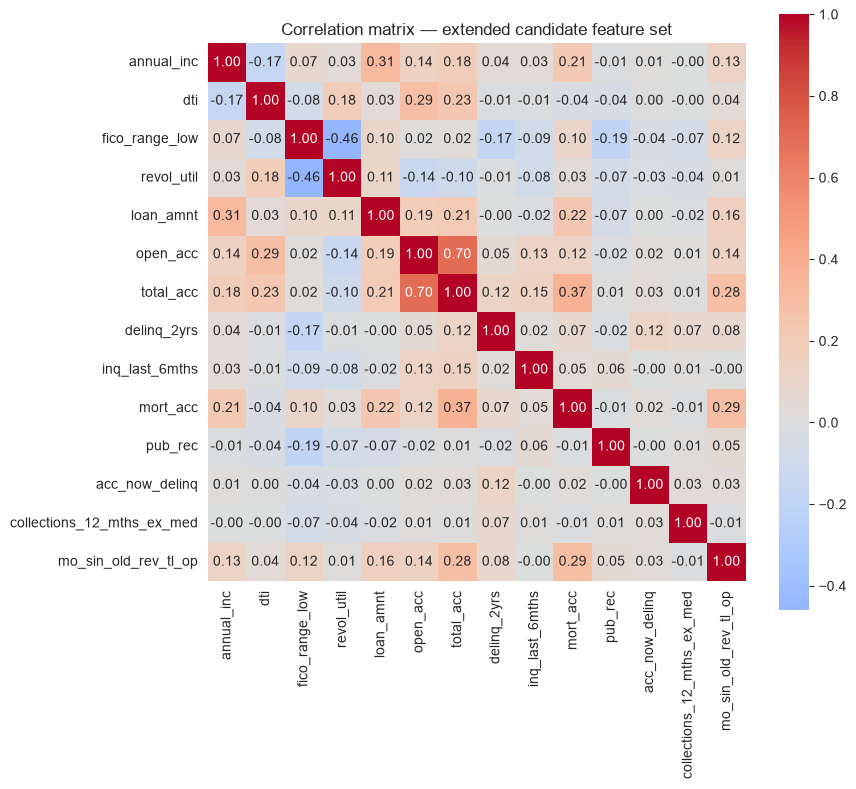

In [22]:
corr_features_extended = [
    'annual_inc', 'dti', 'fico_range_low', 'revol_util',
    'loan_amnt', 'open_acc', 'total_acc',
    'delinq_2yrs', 'inq_last_6mths', 'mort_acc', 'pub_rec',
    'acc_now_delinq', 'collections_12_mths_ex_med', 'mo_sin_old_rev_tl_op',
]
corr_extended = plot_df[corr_features_extended].corr()

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(corr_extended, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=ax)
ax.set_title('Correlation matrix — extended candidate feature set')
plt.tight_layout()
plt.show()


**Redundancy check:** `open_acc`/`total_acc` is the strongest pair in the full
candidate set (r=0.70) — `total_acc` counts `open_acc` plus every closed
account, so they move together almost by construction. `fico_range_low` is
moderately (and sensibly) related to `revol_util` (r=-0.48) — lower FICO
tracks with higher utilization, expected structure rather than a redundancy
problem. Among the new bureau features, no pair exceeds |r|=0.5: `mort_acc`
vs. `total_acc` sits at r≈0.37 (a mortgage does count toward `total_acc`, so
some positive correlation is expected, but not strongly enough to call
redundant) and vs. `open_acc` is weaker still (r≈0.12); `acc_now_delinq` vs.
`delinq_2yrs` sits at r≈0.12 — much weaker overlap than the naming suggests,
since one is a current snapshot and the other a trailing 2-year count. None of
this rules features in or out — per `CLAUDE.md`, that call is left to
L1-regularization-driven feature selection in notebook 03, not manual dropping
here.


**Product framing — why `grade`/`int_rate` won't be in the Phase 1 feature set:**
Phase 1's actual job is to simulate a loan officer scoring a *not-yet-underwritten*
applicant — before LendingClub has assigned a grade or priced a rate. `grade` is
perfectly monotonic with the target (section 2) and `int_rate` is the strongest
single numeric correlate of target shown in this notebook (r=0.26) — but both are
LendingClub's own post-underwriting risk output, not information available at
application time. Using them would leak the answer into the input. So despite
being the strongest predictors in this notebook, `grade`, `sub_grade`, and
`int_rate` are excluded from the Phase 1 feature set in notebook `03_`.

The grade-monotonicity check and the correlation analysis above still earn their
place in this notebook — they validate that the target behaves sensibly and that
LendingClub's own risk ranking is internally consistent — they just don't double
as a Phase 1 feature shortlist. This doesn't touch Phase 2 (vintage/hazard
analysis on already-issued, already-graded loans), where `grade` remains a
legitimate segmentation variable.


## 9. Missingness by feature and vintage

Per `CLAUDE.md`, some Phase-1 candidate features are null because of **schema
growth** (didn't exist yet — null rate collapses after a cutoff year), others are
null because they're **structurally sparse** (e.g. joint-application-only
fields, null regardless of vintage). Cross-tabbing against `issue_year` shows
which is which — they need different handling.


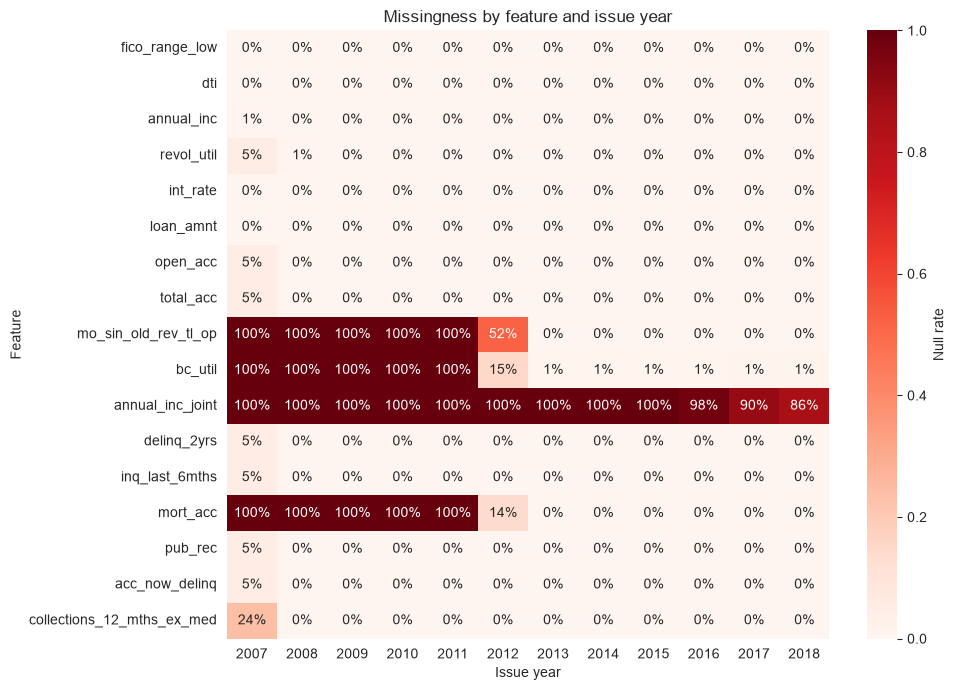

In [23]:
candidate_cols = [
    'fico_range_low', 'dti', 'annual_inc', 'revol_util', 'int_rate',
    'loan_amnt', 'open_acc', 'total_acc',
    'mo_sin_old_rev_tl_op', 'bc_util', 'annual_inc_joint',
    'delinq_2yrs', 'inq_last_6mths', 'mort_acc', 'pub_rec',
    'acc_now_delinq', 'collections_12_mths_ex_med',
]
null_by_year = df.groupby('issue_year')[candidate_cols].apply(lambda x: x.isnull().mean())

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(null_by_year.T, cmap='Reds', annot=True, fmt='.0%',
            cbar_kws={'label': 'Null rate'}, ax=ax)
ax.set_title('Missingness by feature and issue year')
ax.set_xlabel('Issue year')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

## 10. EDA summary

- **Grade:** perfectly monotonic A→G (6.0% → 49.7% default) — strongest categorical signal in the dataset.
- **int_rate:** strongest single numeric correlate with target (r=0.26), but it's LendingClub's own risk-based pricing off of grade — largely redundant with grade, not an independent signal.
- **fico_range_low, dti, revol_util:** modest, correctly-signed correlations with target (r=-0.13, 0.11, 0.06). Useful but weaker standalone than grade.
- **annual_inc:** essentially no linear signal alone (r=-0.04) despite being a headline underwriting field — likely only useful combined with loan size (e.g. a loan/income ratio) rather than as a raw level.
- **term:** large observed gap (36mo 16.0% vs. 60mo 32.5%), but resolved 60-month loans skew toward older vintages since recent 60mo cohorts are still mostly censored (section 5) — revisit vintage-adjusted before trusting the full size of this gap.
- **purpose:** real spread (wedding 12.4% → small_business 29.9%), but `renewable_energy` (n=936) and `educational` (n=423) are too thin to trust at face value.
- **Redundant / drop candidates:** `open_acc` and `total_acc` (r=0.72) — keep one or combine. `int_rate` vs. `grade` — pick one representation, not both. `fico_range_low`/`fico_range_high` are known near-duplicates (not both used here).
- **Missingness:** confirms the CLAUDE.md split — `mo_sin_old_rev_tl_op`/`bc_util` are schema-growth nulls (~100% before 2012-13, ~0% after; usable only for `issue_year >= 2013`), while `annual_inc_joint` is structurally sparse (94%+ null in every year, only populated for joint applications).
- **Surprise worth flagging:** `annual_inc`'s near-zero raw correlation is the most counter-intuitive result here — worth a feature-engineering note (DTI-style ratio) before Phase 1 rather than dropping the field outright. `annual_inc` also has 1,667 exact-zero rows, worth a data-quality check before modeling.
- **Product framing:** despite being the strongest predictors shown here, `grade`, `sub_grade`, and `int_rate` are excluded from the Phase 1 feature set in notebook `03_` — Phase 1 scores a not-yet-underwritten applicant, and all three are LendingClub's own post-underwriting output (grade/rate assigned *after* the decision Phase 1 is trying to simulate). They remain legitimate for Phase 2, which analyzes already-graded, already-issued loans.
- **Age proxies:** neither `emp_length_years` (r=-0.01) nor `credit_history_years` (r=-0.03) shows meaningful separation between defaulters and non-defaulters — both are far weaker than `fico_range_low` or `dti`, so they're worth including in notebook `03_` as minor features but shouldn't be expected to meaningfully substitute for the missing age field.
- **New bureau features:** `inq_last_6mths` (a clean ~10-point monotonic spread, 17.9%→28.1%) and `mo_sin_old_rev_tl_op` (27.1%→17.5%, longer history = lower risk) look the most promising of the seven added for the notebook 03/04 feature expansion; `delinq_2yrs`, `pub_rec`, `collections_12_mths_ex_med`, and `acc_now_delinq` all move in the expected direction but are concentrated enough at zero to add only modest lift. `mort_acc` is the notable surprise — default rate falls as mortgage-account count rises (23.6%→14.9%), more likely a homeownership/stability proxy than a risk signal. None of the seven correlates above |r|=0.5 with each other or the original feature set, so no redundancy-driven exclusions are needed going in; leave selection to L1 regularization in notebook 03.